## Importing Dependencies

In [1]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## LMC labelling function and helper function

In [2]:
def compute_lmc_subhalo_flags(
    node_index,
    parent_index,
    node_label_lmc,
    tree_starts,
    tree_counts,
):
    """
    Calculate LMC-subhalo flags using NumPy arrays.

    Trees with anything other than exactly one LMC-labeled row
    are excluded through the returned valid_tree_mask.
    """
    n_nodes = len(node_index)

    is_lmc_subhalo = np.zeros(n_nodes, dtype=bool)
    valid_tree_mask = np.zeros(n_nodes, dtype=bool)
    discarded = []

    for tree_number, (start, count) in enumerate(
        zip(tree_starts, tree_counts)
    ):
        start = int(start)
        count = int(count)
        stop = start + count

        tree_nodes = node_index[start:stop]
        tree_parents = parent_index[start:stop]
        tree_labels = node_label_lmc[start:stop]

        lmc_rows = np.flatnonzero(tree_labels == 1)

        if len(lmc_rows) != 1:
            discarded.append({
                "tree_number": tree_number,
                "lmc_count": len(lmc_rows),
                "node_count": count,
            })
            continue

        lmc_row = int(lmc_rows[0])

        # Sort nodeIndex so parentIndex values can be converted
        # to local row positions without a large Python dictionary.
        order = np.argsort(tree_nodes)
        sorted_nodes = tree_nodes[order]

        if np.any(sorted_nodes[1:] == sorted_nodes[:-1]):
            raise ValueError(
                f"Tree {tree_number} has duplicate nodeIndex values"
            )

        locations = np.searchsorted(
            sorted_nodes,
            tree_parents,
        )

        inside = locations < count
        safe_locations = np.minimum(locations, count - 1)

        matches = (
            inside
            & (
                sorted_nodes[safe_locations]
                == tree_parents
            )
        )

        # Roots initially point to themselves.
        ancestor = np.arange(count, dtype=np.int64)

        # Valid parents point to their local row positions.
        ancestor[matches] = order[locations[matches]]

        # Make the LMC an absorbing endpoint.
        ancestor[lmc_row] = lmc_row

        # Pointer jumping: each iteration doubles the distance
        # traveled toward the root or LMC.
        iterations = max(
            1,
            int(np.ceil(np.log2(count + 1))),
        )

        for _ in range(iterations):
            ancestor = ancestor[ancestor]

        tree_flags = ancestor == lmc_row

        # The LMC is not its own subhalo.
        tree_flags[lmc_row] = False

        valid_tree_mask[start:stop] = True
        is_lmc_subhalo[start:stop] = tree_flags

    discarded_df = pd.DataFrame(
        discarded,
        columns=[
            "tree_number",
            "lmc_count",
            "node_count",
        ],
    )

    return (
        is_lmc_subhalo,
        valid_tree_mask,
        discarded_df,
    )




def read_masked_hdf5_dataset(
    dataset,
    mask,
    chunk_size=50_000,
):
    """
    Read an HDF5 dataset in chunks and return only rows where
    mask is True.
    """
    n_selected = int(np.count_nonzero(mask))

    output = np.empty(
        n_selected,
        dtype=dataset.dtype,
    )

    destination_start = 0
    n_rows = len(mask)

    for start in range(0, n_rows, chunk_size):
        stop = min(start + chunk_size, n_rows)

        chunk_mask = mask[start:stop]
        selected_count = int(
            np.count_nonzero(chunk_mask)
        )

        if selected_count == 0:
            continue

        chunk = dataset[start:stop]

        destination_stop = (
            destination_start + selected_count
        )

        output[
            destination_start:destination_stop
        ] = chunk[chunk_mask]

        destination_start = destination_stop

    return output

## Loading arrays required for ancestry

In [3]:
constrained_filename = "/scratch/abenson/bigRun-t15-v3-4k.hdf5"
constrained_output = "Output103"

constrained_cols = [
    "satellitePositionX",
    "satellitePositionY",
    "satellitePositionZ",
    "basicMass",
    "nodeIndex",
    "basicTimeLastIsolated",
    "satelliteBoundMass",
    "darkMatterProfileScale",
]

with h5py.File(constrained_filename, "r") as f:
    node_path = (
        f"OutputsT/{constrained_output}/nodeData"
    )
    output_path = (
        f"OutputsT/{constrained_output}"
    )

    constrained_tree_start = f[
        f"{output_path}/mergerTreeStartIndex"
    ][:]

    constrained_tree_count = f[
        f"{output_path}/mergerTreeCount"
    ][:]

    constrained_tree_index = f[
        f"{output_path}/mergerTreeIndex"
    ][:]

    node_index = f[
        f"{node_path}/nodeIndex"
    ][:]

    parent_index = f[
        f"{node_path}/parentIndex"
    ][:]

    node_label_lmc = f[
        f"{node_path}/nodeLabelLMC"
    ][:]

    node_is_isolated = f[
        f"{node_path}/nodeIsIsolated"
    ][:]

## Calculate LMC subhalo flags

In [4]:
(
    lmc_subhalo_flags,
    valid_tree_mask,
    discarded_trees,
) = compute_lmc_subhalo_flags(
    node_index,
    parent_index,
    node_label_lmc,
    constrained_tree_start,
    constrained_tree_count,
)

print("Discarded trees:", len(discarded_trees))

if len(discarded_trees):
    print(
        discarded_trees["lmc_count"]
        .value_counts()
        .sort_index()
    )

Discarded trees: 77
lmc_count
2    75
3     2
Name: count, dtype: int64


## Assigning tree IDs

In [5]:
tree_id = np.full(
    len(node_index),
    -1,
    dtype=np.int64,
)

for start, count, idx in zip(
    constrained_tree_start,
    constrained_tree_count,
    constrained_tree_index,
):
    start = int(start)
    stop = start + int(count)
    tree_id[start:stop] = int(idx)

if (tree_id == -1).any():
    raise ValueError(
        "Some rows were not assigned to a tree"
    )

## Remove invalid trees and isolated nodes (Row selection mask)

In [6]:
analysis_mask = (
    valid_tree_mask
    & (node_is_isolated != 1)
)

print(
    f"Keeping {analysis_mask.sum():,} "
    f"of {len(analysis_mask):,} rows"
)

Keeping 13,285,973 of 13,633,498 rows


## Reading selected columns in chunks

In [7]:
constrained_data = {}

with h5py.File(constrained_filename, "r") as f:
    node_path = (
        f"OutputsT/{constrained_output}/nodeData"
    )

    for column in constrained_cols:
        print("Loading:", column)

        dataset = f[
            f"{node_path}/{column}"
        ]

        constrained_data[column] = (
            read_masked_hdf5_dataset(
                dataset,
                analysis_mask,
                chunk_size=50_000,
            )
        )

constrained_data["tree_id"] = (
    tree_id[analysis_mask]
)

constrained_data["isLMCSubhalo"] = (
    lmc_subhalo_flags[analysis_mask]
)

Loading: satellitePositionX
Loading: satellitePositionY
Loading: satellitePositionZ
Loading: basicMass
Loading: nodeIndex
Loading: basicTimeLastIsolated
Loading: satelliteBoundMass
Loading: darkMatterProfileScale


## Building filtered Dataframe

In [8]:
constrained_df = pd.DataFrame(
    constrained_data,
    copy=False,
)

## Calculating absolute distance

In [9]:
x = constrained_df["satellitePositionX"].to_numpy()
y = constrained_df["satellitePositionY"].to_numpy()
z = constrained_df["satellitePositionZ"].to_numpy()

constrained_df["absolute_distance"] = np.sqrt(
    x * x + y * y + z * z
)

print("Final rows:", len(constrained_df))
print(
    "Remaining trees:",
    constrained_df["tree_id"].nunique(),
)
print(
    "LMC subhalo nodes:",
    constrained_df["isLMCSubhalo"].sum(),
)

constrained_df.describe()

Final rows: 13285973
Remaining trees: 4019
LMC subhalo nodes: 949878


,satellitePositionX,satellitePositionY,satellitePositionZ,basicMass,nodeIndex,basicTimeLastIsolated,satelliteBoundMass,darkMatterProfileScale,tree_id,absolute_distance
count,1.328597e+07,1.328597e+07,1.328597e+07,1.328597e+07,1.328597e+07,1.328597e+07,1.328597e+07,1.328597e+07,1.328597e+07,1.328597e+07
mean,6.077668e-04,7.895213e-04,2.860290e-04,3.313411e+08,3.562321e+04,4.866049e+00,4.850345e+07,6.702891e-04,2.045503e+03,3.797470e-01
std,3.673128e-01,3.674061e-01,3.666645e-01,4.615797e+09,3.313974e+04,3.689978e+00,1.299729e+09,6.470503e-04,1.182827e+03,5.100412e-01
min,-6.544473e+00,-5.443103e+00,-5.727299e+00,9.002803e+06,1.400000e+01,1.122697e-01,9.803541e+05,3.452982e-05,2.000000e+00,9.220818e-05
25%,-8.235510e-02,-8.203513e-02,-8.220871e-02,1.467491e+07,1.906000e+03,1.841293e+00,2.263951e+06,3.633774e-04,1.019000e+03,1.007400e-01
50%,-2.839423e-05,1.343289e-04,4.393552e-06,2.654156e+07,2.904800e+04,3.765288e+00,4.917635e+06,5.235412e-04,2.045000e+03,1.886954e-01
75%,8.225030e-02,8.285723e-02,8.230184e-02,6.955031e+07,6.538500e+04,7.135647e+00,1.115969e+07,7.646933e-04,3.068000e+03,3.999974e-01
max,7.199524e+00,5.906634e+00,6.759116e+00,5.003908e+11,1.099750e+05,1.500000e+01,4.923843e+11,4.173188e-02,4.096000e+03,7.579784e+00


## Loading Wisha's Unconstrained Dataset

In [10]:
unconstrained_filename = "/scratch/abenson/bigRun-uncon-v3-4k.hdf5"
unconstrained_output = "Output3"

unconstrained_cols = [
    "satellitePositionX",
    "satellitePositionY",
    "satellitePositionZ",
    "basicMass",
    "nodeIndex",
    "basicTimeLastIsolated",
    "satelliteBoundMass",
    "darkMatterProfileScale",
]

## Loading metadata and the filtering column

In [11]:
with h5py.File(unconstrained_filename, "r") as f:
    node_path = (
        f"Outputs/{unconstrained_output}/nodeData"
    )
    output_path = (
        f"Outputs/{unconstrained_output}"
    )

    unconstrained_tree_start = f[
        f"{output_path}/mergerTreeStartIndex"
    ][:]

    unconstrained_tree_count = f[
        f"{output_path}/mergerTreeCount"
    ][:]

    unconstrained_tree_index = f[
        f"{output_path}/mergerTreeIndex"
    ][:]

    unconstrained_node_is_isolated = f[
        f"{node_path}/nodeIsIsolated"
    ][:]

## Validating tree ranges

In [12]:
unconstrained_starts = np.asarray(
    unconstrained_tree_start,
    dtype=np.int64,
)

unconstrained_counts = np.asarray(
    unconstrained_tree_count,
    dtype=np.int64,
)

unconstrained_n_nodes = len(
    unconstrained_node_is_isolated
)

if unconstrained_starts[0] != 0:
    raise ValueError(
        "The first unconstrained tree does not start at row 0"
    )

if not np.all(
    unconstrained_starts[1:]
    == (
        unconstrained_starts[:-1]
        + unconstrained_counts[:-1]
    )
):
    raise ValueError(
        "Unconstrained merger-tree ranges are not contiguous"
    )

if (
    unconstrained_starts[-1]
    + unconstrained_counts[-1]
    != unconstrained_n_nodes
):
    raise ValueError(
        "Tree ranges do not cover all unconstrained nodes"
    )

print(
    "Total unconstrained nodes:",
    f"{unconstrained_n_nodes:,}",
)

print(
    "Total unconstrained trees:",
    len(unconstrained_tree_count),
)

Total unconstrained nodes: 13,096,864
Total unconstrained trees: 4096


## Building tree IDs and analysis mask

In [13]:
unconstrained_analysis_mask = (
    unconstrained_node_is_isolated != 1
)

print(
    f"Keeping "
    f"{unconstrained_analysis_mask.sum():,} "
    f"of {unconstrained_n_nodes:,} nodes"
)

unconstrained_tree_id = np.full(
    unconstrained_n_nodes,
    -1,
    dtype=np.int64,
)

for start, count, idx in zip(
    unconstrained_tree_start,
    unconstrained_tree_count,
    unconstrained_tree_index,
):
    start = int(start)
    stop = start + int(count)

    unconstrained_tree_id[start:stop] = int(idx)

if (unconstrained_tree_id == -1).any():
    raise ValueError(
        "Some unconstrained nodes were not assigned to a tree"
    )

Keeping 13,092,768 of 13,096,864 nodes


## Read selected rows in chunks

In [14]:
unconstrained_data = {}

with h5py.File(unconstrained_filename, "r") as f:
    node_path = (
        f"Outputs/{unconstrained_output}/nodeData"
    )

    for column in unconstrained_cols:
        print("Loading:", column)

        dataset = f[
            f"{node_path}/{column}"
        ]

        unconstrained_data[column] = (
            read_masked_hdf5_dataset(
                dataset,
                unconstrained_analysis_mask,
                chunk_size=50_000,
            )
        )

Loading: satellitePositionX
Loading: satellitePositionY
Loading: satellitePositionZ
Loading: basicMass
Loading: nodeIndex
Loading: basicTimeLastIsolated
Loading: satelliteBoundMass
Loading: darkMatterProfileScale


## Assigning tree IDs

In [15]:
unconstrained_data["tree_id"] = (
    unconstrained_tree_id[
        unconstrained_analysis_mask
    ]
)

## Construct the Dataframe

In [16]:
unconstrained_df = pd.DataFrame(
    unconstrained_data,
    copy=False,
)

unconstrained_df.describe()

,satellitePositionX,satellitePositionY,satellitePositionZ,basicMass,nodeIndex,basicTimeLastIsolated,satelliteBoundMass,darkMatterProfileScale,tree_id
count,1.309277e+07,1.309277e+07,1.309277e+07,1.309277e+07,1.309277e+07,1.309277e+07,1.309277e+07,1.309277e+07,1.309277e+07
mean,-1.217639e-03,-4.290044e-04,-4.405926e-04,3.105480e+08,3.506410e+04,4.662798e+00,4.572026e+07,6.665757e-04,2.047018e+03
std,3.283030e-01,3.278746e-01,3.262830e-01,4.673886e+09,3.166932e+04,3.447363e+00,1.449829e+09,6.266803e-04,1.181554e+03
min,-5.446772e+00,-5.368300e+00,-5.599186e+00,9.004678e+06,2.000000e+00,9.463682e-02,9.727407e+05,3.438235e-05,1.000000e+00
25%,-8.048227e-02,-8.021530e-02,-8.023667e-02,1.469107e+07,1.844000e+03,1.793249e+00,2.248807e+06,3.625417e-04,1.023000e+03
50%,-1.008584e-04,-3.840170e-05,-3.592907e-05,2.660987e+07,3.078900e+04,3.696883e+00,4.886340e+06,5.227703e-04,2.047000e+03
75%,7.988094e-02,8.001559e-02,8.002187e-02,6.971343e+07,6.243300e+04,6.875951e+00,1.119243e+07,7.637692e-04,3.069000e+03
max,6.127394e+00,6.443330e+00,5.762915e+00,4.970613e+11,1.073580e+05,1.380048e+01,4.970613e+11,4.663596e-02,4.096000e+03


## Calculating absolute distance

In [17]:
x = unconstrained_df[
    "satellitePositionX"
].to_numpy()

y = unconstrained_df[
    "satellitePositionY"
].to_numpy()

z = unconstrained_df[
    "satellitePositionZ"
].to_numpy()

absolute_distance = np.square(x)
temporary = np.empty_like(absolute_distance)

np.square(y, out=temporary)
absolute_distance += temporary

np.square(z, out=temporary)
absolute_distance += temporary

np.sqrt(
    absolute_distance,
    out=absolute_distance,
)

unconstrained_df["absolute_distance"] = (
    absolute_distance
)

## Constants

In [18]:
min_smc_mass = 3.0e10
max_smc_mass = 5.0e10

min_smc_distance = 0.0145
max_smc_distance = 0.0345

total_constrained = len(constrained_df)
total_unconstrained = len(unconstrained_df)

## Finding SMC Candidates In Constrained Data

In [19]:
smc_candidate_mask = (
    (constrained_df["basicMass"] > min_smc_mass) &
    (constrained_df["basicMass"] < max_smc_mass) &
    (constrained_df["absolute_distance"] > min_smc_distance) &
    (constrained_df["absolute_distance"] < max_smc_distance) &
    (~constrained_df["isLMCSubhalo"])
)

selected = constrained_df[smc_candidate_mask]
selected_ids = selected["tree_id"].tolist()
unique_selected_ids = set(selected_ids)
tree_id_with_multiple_candidates = selected["tree_id"].value_counts()
trees_with_multiple_candidates = tree_id_with_multiple_candidates[tree_id_with_multiple_candidates > 1].index.tolist()
trees_with_single_candidate = tree_id_with_multiple_candidates[tree_id_with_multiple_candidates == 1].index.tolist()

print(selected.columns)
print("Selected tree IDs:", selected_ids)
print("Trees with multiple candidates:", trees_with_multiple_candidates)
print("Trees with single candidate:", trees_with_single_candidate)
print("Number selected:", len(selected))
print("Number of unique tree IDs:", len(unique_selected_ids))
print("Number of trees with multiple candidates:", len(trees_with_multiple_candidates))
print("Number of trees with single candidate:", len(trees_with_single_candidate))
print("Total number of trees in the dataset:", constrained_df["tree_id"].nunique())
print("Percentage of trees with at least one candidate:", len(unique_selected_ids) / constrained_df["tree_id"].nunique() * 100)


Index(['satellitePositionX', 'satellitePositionY', 'satellitePositionZ',
       'basicMass', 'nodeIndex', 'basicTimeLastIsolated', 'satelliteBoundMass',
       'darkMatterProfileScale', 'tree_id', 'isLMCSubhalo',
       'absolute_distance'],
      dtype='object')
Selected tree IDs: [4073, 4073, 4073, 4064, 4095, 4095, 4077, 4077, 4094, 4088, 4061, 4036, 4081, 4049, 4050, 4059, 4078, 4055, 4032, 4021, 4014, 4007, 4008, 4004, 3998, 3991, 3990, 3981, 3964, 3961, 3963, 3947, 3940, 3944, 3933, 3935, 3934, 3928, 3927, 3921, 3892, 3894, 3893, 3879, 3877, 3868, 3859, 3852, 3848, 3847, 3843, 3838, 3832, 3829, 3819, 3821, 3825, 3813, 3817, 3807, 3804, 3805, 3795, 3791, 3784, 3784, 3779, 3780, 3776, 3769, 3772, 3758, 3762, 3751, 3743, 3738, 3740, 3735, 3726, 3710, 3702, 3699, 3699, 3693, 3703, 3703, 3685, 3685, 3689, 3689, 3687, 3688, 3677, 3658, 3664, 3642, 3633, 3625, 3628, 3624, 3623, 3623, 3609, 3610, 3597, 3583, 3580, 3581, 3573, 3570, 3572, 3574, 3567, 3564, 3569, 3569, 3555, 3552, 3550, 35

## SMC Candidates of trees with Multiple Candidates

In [20]:
special_smc_candidate_mask = (
    (constrained_df["tree_id"].isin(trees_with_multiple_candidates)) &
    (constrained_df["basicMass"] > min_smc_mass) &
    (constrained_df["basicMass"] < max_smc_mass) &
    (constrained_df["absolute_distance"] > min_smc_distance) &
    (constrained_df["absolute_distance"] < max_smc_distance)
)

special_candidates = constrained_df[special_smc_candidate_mask]
print("Number of special candidates:", len(special_candidates))

Number of special candidates: 138


## SMC Candidates from trees with only one SMC

In [21]:
regular_candidate_mask = (
    (constrained_df["tree_id"].isin(trees_with_single_candidate)) &
    (constrained_df["basicMass"] > min_smc_mass) &
    (constrained_df["basicMass"] < max_smc_mass) &
    (constrained_df["absolute_distance"] > min_smc_distance) &
    (constrained_df["absolute_distance"] < max_smc_distance)
)

regular_candidates = constrained_df[regular_candidate_mask]
print("Number of unique candidates:", len(regular_candidates))


Number of unique candidates: 804


## Histograms of Infall times of Regular Candidates vs Special Candidates

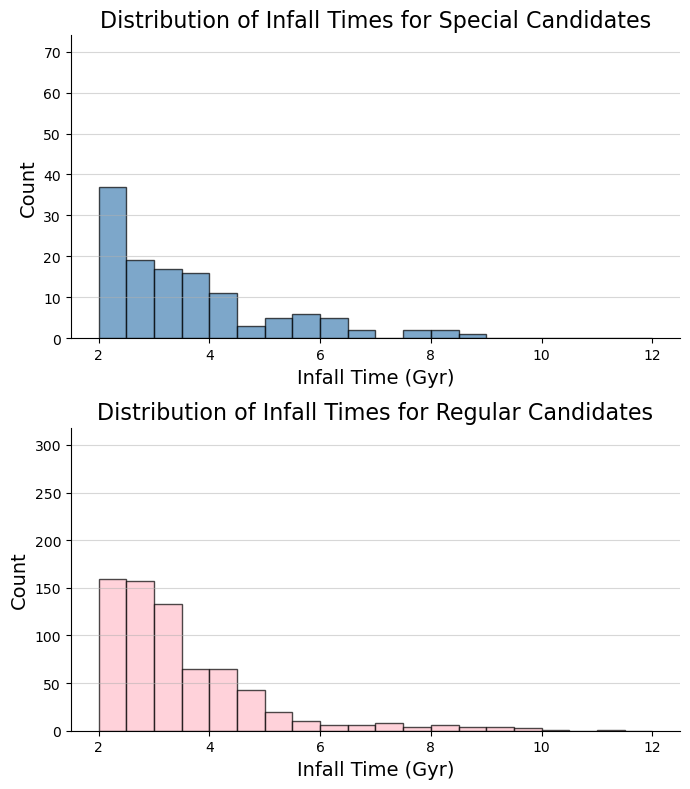

In [22]:
fig, ax = plt.subplots(2, 1, figsize = (7, 8))
bins = np.arange(2, 12.5, 0.5)

ax[0].hist(special_candidates["basicTimeLastIsolated"], bins=bins, color = "steelblue", edgecolor='black', alpha=0.7)
ax[0].set_title("Distribution of Infall Times for Special Candidates", fontsize=16)
ax[0].set_xlabel("Infall Time (Gyr)", fontsize=14)
ax[0].set_ylabel("Count", fontsize=14)
ax[0].set_ymargin(1)
ax[0].grid(axis='y', alpha=0.5)

ax[1].hist(regular_candidates["basicTimeLastIsolated"], bins=bins, color = "pink", edgecolor='black', alpha=0.7)
ax[1].set_title("Distribution of Infall Times for Regular Candidates", fontsize=16)
ax[1].set_xlabel("Infall Time (Gyr)", fontsize=14)
ax[1].set_ylabel("Count", fontsize=14)
ax[1].set_ymargin(1)
ax[1].grid(axis='y', alpha=0.5)

for axis in ax:
    axis.spines['top'].set_visible(False)
    axis.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()



## Histogram of Absolute Distances of SMC Candidates

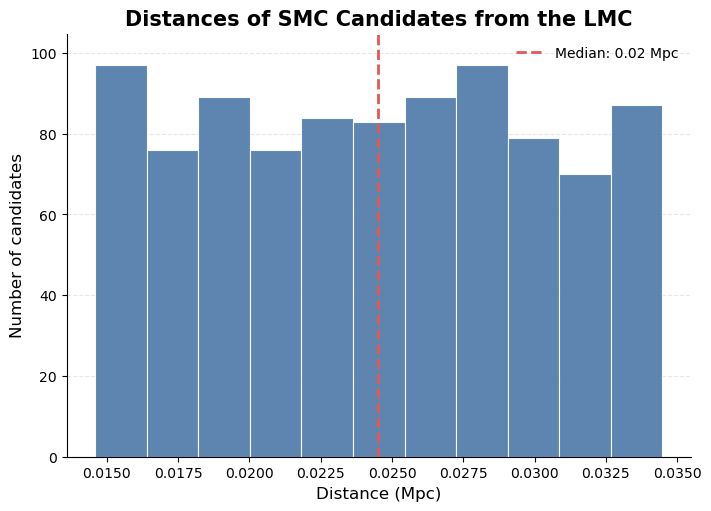

In [23]:
distances = selected["absolute_distance"].dropna()

fig, ax = plt.subplots(figsize=(7, 5), constrained_layout=True)

ax.hist(
    distances,
    bins="auto",
    color="#4C78A8",
    edgecolor="white",
    linewidth=0.8,
    alpha=0.9,
)

median_distance = distances.median()
ax.axvline(
    median_distance,
    color="#E45756",
    linestyle="--",
    linewidth=2,
    label=f"Median: {median_distance:.2f} Mpc",
)

ax.set(
    title="Distances of SMC Candidates from the LMC",
    xlabel="Distance (Mpc)",
    ylabel="Number of candidates",
)

ax.title.set_fontsize(15)
ax.title.set_weight("bold")
ax.xaxis.label.set_fontsize(12)
ax.yaxis.label.set_fontsize(12)

ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.set_axisbelow(True)
ax.margins(y=0.08)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)

plt.show()

## Cumulative Mass Function

In [24]:
def cum_mass_constrained(m_sub):
    m_sub = np.array(m_sub)
    sorted_masses = np.sort(m_sub)

    idx = np.searchsorted(sorted_masses, sorted_masses, side="right")
    N = (len(sorted_masses) - idx) / total_constrained
    return sorted_masses, N

def cum_mass_unconstrained(m_sub):
    m_sub = np.array(m_sub)
    sorted_masses = np.sort(m_sub)

    idx = np.searchsorted(sorted_masses, sorted_masses, side="right")
    N = (len(sorted_masses) - idx) / total_unconstrained
    return sorted_masses, N

## Generate Xs and Ys From Constrained

In [25]:
constrained_m_sub_bm = constrained_df["basicMass"].to_list()
constrained_x_bm, constrained_y_bm = cum_mass_constrained(constrained_m_sub_bm)

constrained_m_sub_sbm = constrained_df["satelliteBoundMass"].to_list()
constrained_x_sbm, constrained_y_sbm = cum_mass_constrained(constrained_m_sub_sbm)

print(constrained_x_bm)
print(constrained_y_bm)
print(constrained_x_sbm)
print(constrained_y_sbm)

[9.00280268e+06 9.00381478e+06 9.00413353e+06 ... 4.97576598e+11
 4.98433057e+11 5.00390846e+11]
[9.99999925e-01 9.99999849e-01 9.99999774e-01 ... 1.50534703e-07
 7.52673515e-08 0.00000000e+00]
[9.80354071e+05 9.87256413e+05 9.88456410e+05 ... 4.66247007e+11
 4.73775446e+11 4.92384256e+11]
[9.99999925e-01 9.99999849e-01 9.99999774e-01 ... 1.50534703e-07
 7.52673515e-08 0.00000000e+00]


## Generate Xs and Ys From Unconstrained

In [26]:
unconstrained_m_sub_bm = unconstrained_df["basicMass"].to_list()
unconstrained_x_bm, unconstrained_y_bm = cum_mass_unconstrained(unconstrained_m_sub_bm)

unconstrained_m_sub_sbm = unconstrained_df["satelliteBoundMass"].to_list()
unconstrained_x_sbm, unconstrained_y_sbm = cum_mass_unconstrained(unconstrained_m_sub_sbm)

print(unconstrained_x_bm)
print(unconstrained_y_bm)
print(unconstrained_x_sbm)
print(unconstrained_y_sbm)

[9.00467821e+06 9.00479827e+06 9.00553970e+06 ... 4.92905731e+11
 4.96167249e+11 4.97061347e+11]
[9.99999924e-01 9.99999847e-01 9.99999771e-01 ... 1.52756086e-07
 7.63780432e-08 0.00000000e+00]
[9.72740729e+05 9.73442371e+05 9.73462186e+05 ... 4.90223600e+11
 4.95846451e+11 4.97061347e+11]
[9.99999924e-01 9.99999847e-01 9.99999771e-01 ... 1.52756086e-07
 7.63780432e-08 0.00000000e+00]


## Mass Function Curves

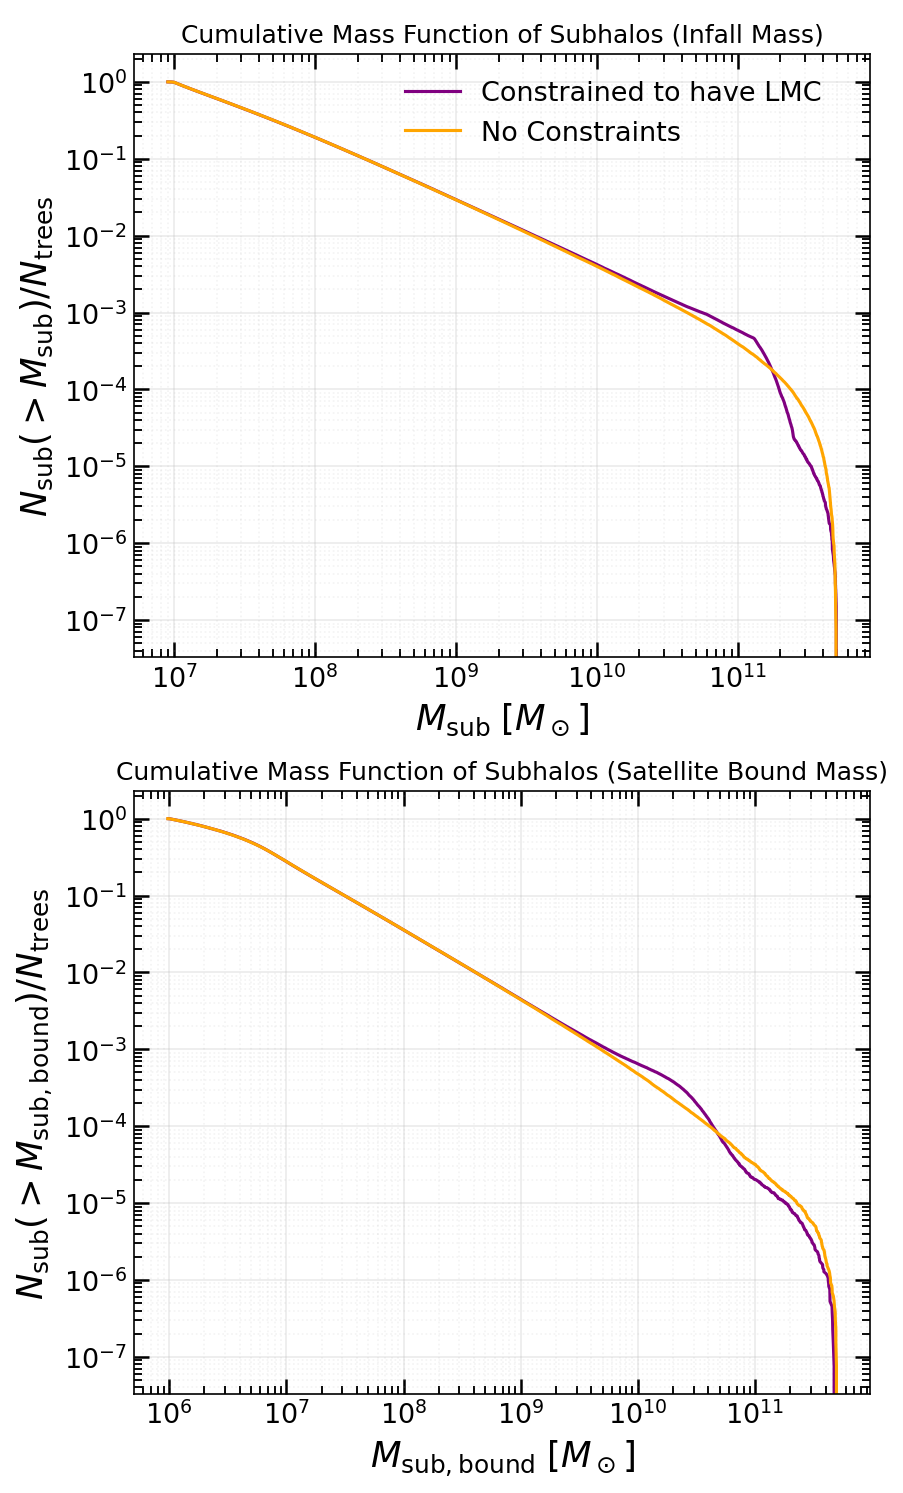

In [27]:
fig, ax = plt.subplots(2, 1, figsize= (6, 10), dpi= 150)

ax[0].plot(constrained_x_bm, constrained_y_bm, color= "purple")
ax[0].plot(unconstrained_x_bm, unconstrained_y_bm, color= "orange")
ax[0].set_xscale("log")
ax[0].set_yscale("log")

ax[0].set_xlabel(r"$M_{\rm sub}\;[M_\odot]$", fontsize=17)
ax[0].set_ylabel(r"$N_{\rm sub}(>M_{\rm sub})/ N_{\rm trees}$", fontsize=17)

ax[0].tick_params(axis="both", which="major", labelsize=13, direction="in", length=7, width=1.2)
ax[0].tick_params(axis="both", which="minor", direction="in", length=4, width=0.9)
ax[0].tick_params(top=True, right=True, which="both")

ax[0].grid(True, which="major", linestyle="-", alpha=0.25)
ax[0].grid(True, which="minor", linestyle=":", alpha=0.15)
ax[0].title.set_text("Cumulative Mass Function of Subhalos (Infall Mass)")

ax[1].plot(constrained_x_sbm, constrained_y_sbm, color= "purple")
ax[1].plot(unconstrained_x_sbm, unconstrained_y_sbm, color= "orange")
ax[1].set_xscale("log")
ax[1].set_yscale("log")

ax[1].set_xlabel(r"$M_{\rm sub, bound}\;[M_\odot]$", fontsize=17)
ax[1].set_ylabel(r"$N_{\rm sub}(>M_{\rm sub, bound})/ N_{\rm trees}$", fontsize=17)

ax[1].tick_params(axis="both", which="major", labelsize=13, direction="in", length=7, width=1.2)
ax[1].tick_params(axis="both", which="minor", direction="in", length=4, width=0.9)
ax[1].tick_params(top=True, right=True, which="both")

ax[1].grid(True, which="major", linestyle="-", alpha=0.25)
ax[1].grid(True, which="minor", linestyle=":", alpha=0.15)
ax[1].title.set_text("Cumulative Mass Function of Subhalos (Satellite Bound Mass)")

fig.legend(["Constrained to have LMC", "No Constraints"], fontsize=13, loc="upper right", frameon=False, borderpad=2.5)
fig.tight_layout()
plt.show()


## SMCs Still Associated with their Subhalos vs Not Associated

In [28]:
bound_smcs = selected[
    (selected["nodeLabelIsLMCSubhalo"] == 1)
]
regular_bound_smcs = regular_candidates[
    (regular_candidates["nodeLabelIsLMCSubhalo"] == 1)
]
special_bound_smcs = special_candidates[
    (special_candidates["nodeLabelIsLMCSubhalo"] == 1)
]

unbound_smcs = selected[
    (selected["nodeLabelIsLMCSubhalo"] == 0)
]
regular_unbound_smcs = regular_candidates[
    (regular_candidates["nodeLabelIsLMCSubhalo"] == 0)
]
special_unbound_smcs = special_candidates[
    (special_candidates["nodeLabelIsLMCSubhalo"] == 0)
]

print (bound_smcs["tree_id"].to_list())
print (regular_bound_smcs["tree_id"].to_list())
print (special_bound_smcs["tree_id"].to_list())
print (unbound_smcs["tree_id"].to_list())
print (regular_unbound_smcs["tree_id"].to_list())
print (special_unbound_smcs["tree_id"].to_list())
print("Number of regular bound SMC candidates:", len(regular_bound_smcs))
print("Number of special bound SMC candidates:", len(special_bound_smcs))
print("Number of bound SMC candidates:", len(bound_smcs))

KeyError: 'nodeLabelIsLMCSubhalo'

## Spatial Directions of SMC Candidates

In [ ]:
x_regular_bound = regular_bound_smcs["satellitePositionX"].to_list()
y_regular_bound = regular_bound_smcs["satellitePositionY"].to_list()
z_regular_bound = regular_bound_smcs["satellitePositionZ"].to_list()

x_special_bound = special_bound_smcs["satellitePositionX"].to_list()
y_special_bound = special_bound_smcs["satellitePositionY"].to_list()
z_special_bound = special_bound_smcs["satellitePositionZ"].to_list()

x_regular_unbound = regular_unbound_smcs["satellitePositionX"].to_list()
y_regular_unbound = regular_unbound_smcs["satellitePositionY"].to_list()
z_regular_unbound = regular_unbound_smcs["satellitePositionZ"].to_list()

x_special_unbound = special_unbound_smcs["satellitePositionX"].to_list()
y_special_unbound = special_unbound_smcs["satellitePositionY"].to_list()
z_special_unbound = special_unbound_smcs["satellitePositionZ"].to_list()

x_actual = 0.0164
y_actual = -0.0167
z_actual = -0.0154

## 3d Plot of Spatial Distributions of SMC Candidates

In [ ]:
SINGLE_BOUND = "#68717A"
MULTIPLE_BOUND = "#0072B2"
UNBOUND = "#D55E00"
OBSERVED = "#C33F88"

TEXT = "#20252B"
AXIS = "#7C858D"
GRID = "#D8DCE0"


def kpc(values):
    return 1000.0 * np.asarray(values)


data = {
    "single_bound": (
        kpc(x_regular_bound),
        kpc(y_regular_bound),
        kpc(z_regular_bound),
    ),
    "multiple_bound": (
        kpc(x_special_bound),
        kpc(y_special_bound),
        kpc(z_special_bound),
    ),
    "single_unbound": (
        kpc(x_regular_unbound),
        kpc(y_regular_unbound),
        kpc(z_regular_unbound),
    ),
    "multiple_unbound": (
        kpc(x_special_unbound),
        kpc(y_special_unbound),
        kpc(z_special_unbound),
    ),
}

observed = np.array(
    [x_actual, y_actual, z_actual],
    dtype=float,
) * 1000.0


fig = plt.figure(
    figsize=(10.5, 8),
    facecolor="white",
)

ax = fig.add_subplot(
    111,
    projection="3d",
)


# Single-SMC, bound:
# darker gray background population
ax.scatter(
    *data["single_bound"],
    s=20,
    c=SINGLE_BOUND,
    marker="o",
    alpha=0.68,
    edgecolors="none",
    depthshade=False,
    rasterized=True,
    label="Single-SMC · bound",
)


# Single-SMC, unbound:
# hollow orange circles
ax.scatter(
    *data["single_unbound"],
    s=40,
    facecolors="none",
    edgecolors=UNBOUND,
    marker="o",
    alpha=0.95,
    linewidths=1.4,
    depthshade=False,
    rasterized=True,
    label="Single-SMC · unbound",
)


# Multiple-SMC, bound:
# blue diamonds
ax.scatter(
    *data["multiple_bound"],
    s=62,
    c=MULTIPLE_BOUND,
    marker="D",
    alpha=1.0,
    edgecolors="white",
    linewidths=0.7,
    depthshade=False,
    label="Multiple-SMC · bound",
)


# Multiple-SMC, unbound:
# filled orange diamonds with dark outlines
ax.scatter(
    *data["multiple_unbound"],
    s=76,
    c=UNBOUND,
    marker="D",
    alpha=1.0,
    edgecolors=TEXT,
    linewidths=0.7,
    depthshade=False,
    label="Multiple-SMC · unbound",
)


# LMC at the origin
ax.scatter(
    [0],
    [0],
    [0],
    s=240,
    c="black",
    marker="*",
    edgecolors="white",
    linewidths=0.9,
    depthshade=False,
    label="_nolegend_",
)


# Observed SMC
ax.scatter(
    [observed[0]],
    [observed[1]],
    [observed[2]],
    s=220,
    c=OBSERVED,
    marker="X",
    edgecolors="white",
    linewidths=0.9,
    depthshade=False,
    label="Observed SMC",
)


# Reference-object labels
ax.text(
    1.5,
    1.5,
    1.5,
    "LMC",
    fontsize=12,
    fontweight="bold",
    color="black",
)

ax.text(
    observed[0] + 1.5,
    observed[1] + 1.5,
    observed[2] + 1.5,
    "Observed SMC",
    fontsize=11,
    fontweight="bold",
    color=OBSERVED,
)


ax.set_title(
    "Spatial Distribution of SMC Candidates",
    fontsize=20,
    fontweight="bold",
    color=TEXT,
    pad=20,
)

ax.set_xlabel(
    "X position (kpc)",
    fontsize=14,
    fontweight="bold",
    color=TEXT,
    labelpad=10,
)

ax.set_ylabel(
    "Y position (kpc)",
    fontsize=14,
    fontweight="bold",
    color=TEXT,
    labelpad=10,
)

ax.set_zlabel(
    "Z position (kpc)",
    fontsize=14,
    fontweight="bold",
    color=TEXT,
    labelpad=10,
)


ax.set_xlim(-45, 45)
ax.set_ylim(-45, 45)
ax.set_zlim(-45, 45)

ticks = [-40, -20, 0, 20, 40]
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_zticks(ticks)

ax.tick_params(
    axis="all",
    labelsize=11,
    colors=TEXT,
)

ax.view_init(
    elev=22,
    azim=-58,
)

ax.set_box_aspect((1, 1, 1))


# Light panes and subtle gridlines
for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
    axis.pane.set_facecolor((1, 1, 1, 1))
    axis.pane.set_edgecolor(AXIS)
    axis.pane.set_alpha(0.06)

    axis._axinfo["grid"]["color"] = GRID
    axis._axinfo["grid"]["linewidth"] = 0.7


# Match the category order used in the 2D legend
handles, labels = ax.get_legend_handles_labels()

legend_order = [0, 2, 1, 3, 4]

ax.legend(
    [handles[i] for i in legend_order],
    [labels[i] for i in legend_order],
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    frameon=False,
    fontsize=12,
    labelcolor=TEXT,
    handletextpad=0.6,
)

fig.subplots_adjust(
    left=0.02,
    right=0.78,
    bottom=0.04,
    top=0.92,
)

plt.show()

## Plot of Different Projections

In [ ]:
from matplotlib.lines import Line2D

# Color-blind-friendly hierarchy:
# gray = background population
# blue = multiple-SMC system
# orange = unbound from LMC
# magenta = observed SMC
SINGLE_BOUND = "#68717A"
MULTIPLE_BOUND = "#0072B2"
UNBOUND = "#D55E00"
OBSERVED = "#C33F88"
TEXT = "#20252B"
AXIS = "#7C858D"
ZERO_LINE = "#D8DCE0"


def kpc(values):
    return 1000.0 * np.asarray(values)


data = {
    "single_bound": (
        kpc(x_regular_bound),
        kpc(y_regular_bound),
        kpc(z_regular_bound),
    ),
    "multiple_bound": (
        kpc(x_special_bound),
        kpc(y_special_bound),
        kpc(z_special_bound),
    ),
    "single_unbound": (
        kpc(x_regular_unbound),
        kpc(y_regular_unbound),
        kpc(z_regular_unbound),
    ),
    "multiple_unbound": (
        kpc(x_special_unbound),
        kpc(y_special_unbound),
        kpc(z_special_unbound),
    ),
}

observed = np.array(
    [x_actual, y_actual, z_actual],
    dtype=float,
) * 1000.0

projections = [
    ("XY", 0, 1, "X position (kpc)", "Y position (kpc)"),
    ("XZ", 0, 2, "X position (kpc)", "Z position (kpc)"),
    ("YZ", 1, 2, "Y position (kpc)", "Z position (kpc)"),
]

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5.2),
    facecolor="white",
)

for panel_number, (
    ax,
    (title, horizontal, vertical, xlabel, ylabel),
) in enumerate(zip(axes, projections)):

    # Subtle origin guides
    ax.axhline(
        0,
        color=ZERO_LINE,
        linewidth=0.8,
        zorder=0,
    )
    ax.axvline(
        0,
        color=ZERO_LINE,
        linewidth=0.8,
        zorder=0,
    )

    # 1. Single-SMC, bound:
    # neutral background population
    ax.scatter(
        data["single_bound"][horizontal],
        data["single_bound"][vertical],
        s=18,
        c=SINGLE_BOUND,
        marker="o",
        alpha=0.48,
        edgecolors="none",
        rasterized=True,
        zorder=1,
    )

    # 2. Single-SMC, unbound:
    # hollow orange circles
    ax.scatter(
        data["single_unbound"][horizontal],
        data["single_unbound"][vertical],
        s=40,
        facecolors="none",
        edgecolors=UNBOUND,
        marker="o",
        alpha=0.95,
        linewidths=1.4,
        rasterized=True,
        zorder=3,
    )

    # 3. Multiple-SMC, bound:
    # blue diamonds
    ax.scatter(
        data["multiple_bound"][horizontal],
        data["multiple_bound"][vertical],
        s=62,
        c=MULTIPLE_BOUND,
        marker="D",
        alpha=1.0,
        edgecolors="white",
        linewidths=0.7,
        zorder=4,
    )

    # 4. Multiple-SMC, unbound:
    # filled orange diamonds with dark outlines
    ax.scatter(
        data["multiple_unbound"][horizontal],
        data["multiple_unbound"][vertical],
        s=76,
        c=UNBOUND,
        marker="D",
        alpha=1.0,
        edgecolors=TEXT,
        linewidths=0.7,
        zorder=5,
    )

    # LMC at the origin
    ax.scatter(
        0,
        0,
        s=200,
        c="black",
        marker="*",
        edgecolors="white",
        linewidths=0.9,
        zorder=7,
    )

    # Observed SMC
    ax.scatter(
        observed[horizontal],
        observed[vertical],
        s=200,
        c=OBSERVED,
        marker="X",
        edgecolors="white",
        linewidths=0.9,
        zorder=8,
    )

    # Label reference objects only once
    if panel_number == 0:
        ax.annotate(
            "LMC",
            (0, 0),
            xytext=(7, 6),
            textcoords="offset points",
            fontsize=13,
            fontweight="bold",
            color="black",
            zorder=9,
        )

        ax.annotate(
            "Observed SMC",
            (observed[horizontal], observed[vertical]),
            xytext=(7, -14),
            textcoords="offset points",
            fontsize=12,
            fontweight="bold",
            color=OBSERVED,
            zorder=9,
        )

    ax.set_title(
        f"{title} projection",
        fontsize=22,
        fontweight="bold",
        color=TEXT,
        pad=10,
    )

    ax.set_xlabel(
        xlabel,
        fontsize=17,
        fontweight="bold",
        color=TEXT,
        labelpad=7,
    )
    ax.set_ylabel(
        ylabel,
        fontsize=17,
        fontweight="bold",
        color=TEXT,
        labelpad=7,
    )

    ax.set_xlim(-45, 45)
    ax.set_ylim(-45, 45)
    ax.set_aspect("equal", adjustable="box")

    ax.set_xticks([-40, -20, 0, 20, 40])
    ax.set_yticks([-40, -20, 0, 20, 40])

    ax.tick_params(
        axis="both",
        labelsize=15,
        colors=TEXT,
        width=1.0,
        length=4,
    )

    ax.grid(False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    for side in ("left", "bottom"):
        ax.spines[side].set_color(AXIS)
        ax.spines[side].set_linewidth(1.0)


legend_handles = [
    Line2D(
        [0], [0],
        marker="o",
        linestyle="none",
        markerfacecolor=SINGLE_BOUND,
        markeredgecolor="none",
        markersize=9,
        label="Single-SMC · bound",
    ),
    Line2D(
        [0], [0],
        marker="D",
        linestyle="none",
        markerfacecolor=MULTIPLE_BOUND,
        markeredgecolor="white",
        markersize=9,
        label="Multiple-SMC · bound",
    ),
    Line2D(
        [0], [0],
        marker="o",
        linestyle="none",
        markerfacecolor="none",
        markeredgecolor=UNBOUND,
        markeredgewidth=1.5,
        markersize=9,
        label="Single-SMC · unbound",
    ),
    Line2D(
        [0], [0],
        marker="D",
        linestyle="none",
        markerfacecolor=UNBOUND,
        markeredgecolor=TEXT,
        markersize=9,
        label="Multiple-SMC · unbound",
    ),
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.975),
    ncol=4,
    frameon=False,
    fontsize=15,
    handletextpad=0.55,
    columnspacing=1.6,
    labelcolor=TEXT,
)

fig.subplots_adjust(
    left=0.055,
    right=0.985,
    bottom=0.15,
    top=0.79,
    wspace=0.20,
)


plt.show()